IMPORTING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1785449451.998100   36115 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785449455.766817   36115 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785449461.039618   36115 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


DATA

In [2]:
data=pd.read_csv('all_stocks_5yr.csv',delimiter=',',on_bad_lines='skip')
print(data.shape)
print(data.sample(7))   

(619040, 7)
              date     open     high      low   close    volume  Name
100658  2017-04-20   33.730   34.245   33.620   34.17   1945641   CBG
315005  2017-02-01   43.200   43.320   42.250   42.50  10608813   JCI
267611  2017-12-12   86.370   87.160   86.110   86.45   3107742   HCA
330634  2016-07-21   51.500   52.210   51.255   51.35   2008148  KORS
376315  2017-12-19  275.415  277.595  274.220  276.56    583380   MHK
303314  2015-06-01   51.780   52.090   51.290   51.82   2488201    IP
58245   2015-03-16   58.220   59.330   58.108   59.31   1139251   APH


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


CONVERTING DATE DATA TYPE 

In [4]:
data['date']=pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


EXPLORATORY DATA ANALYSIS

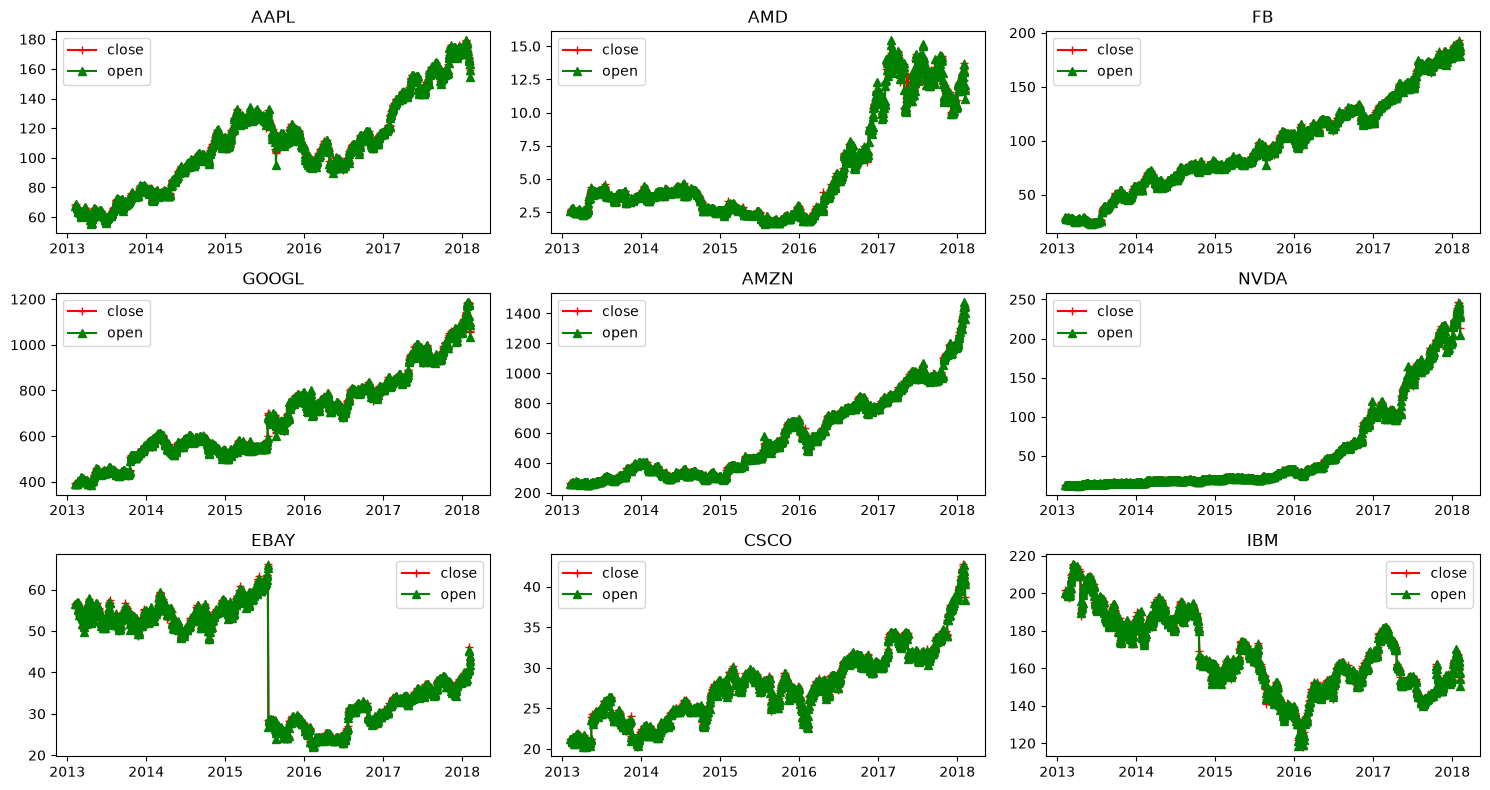

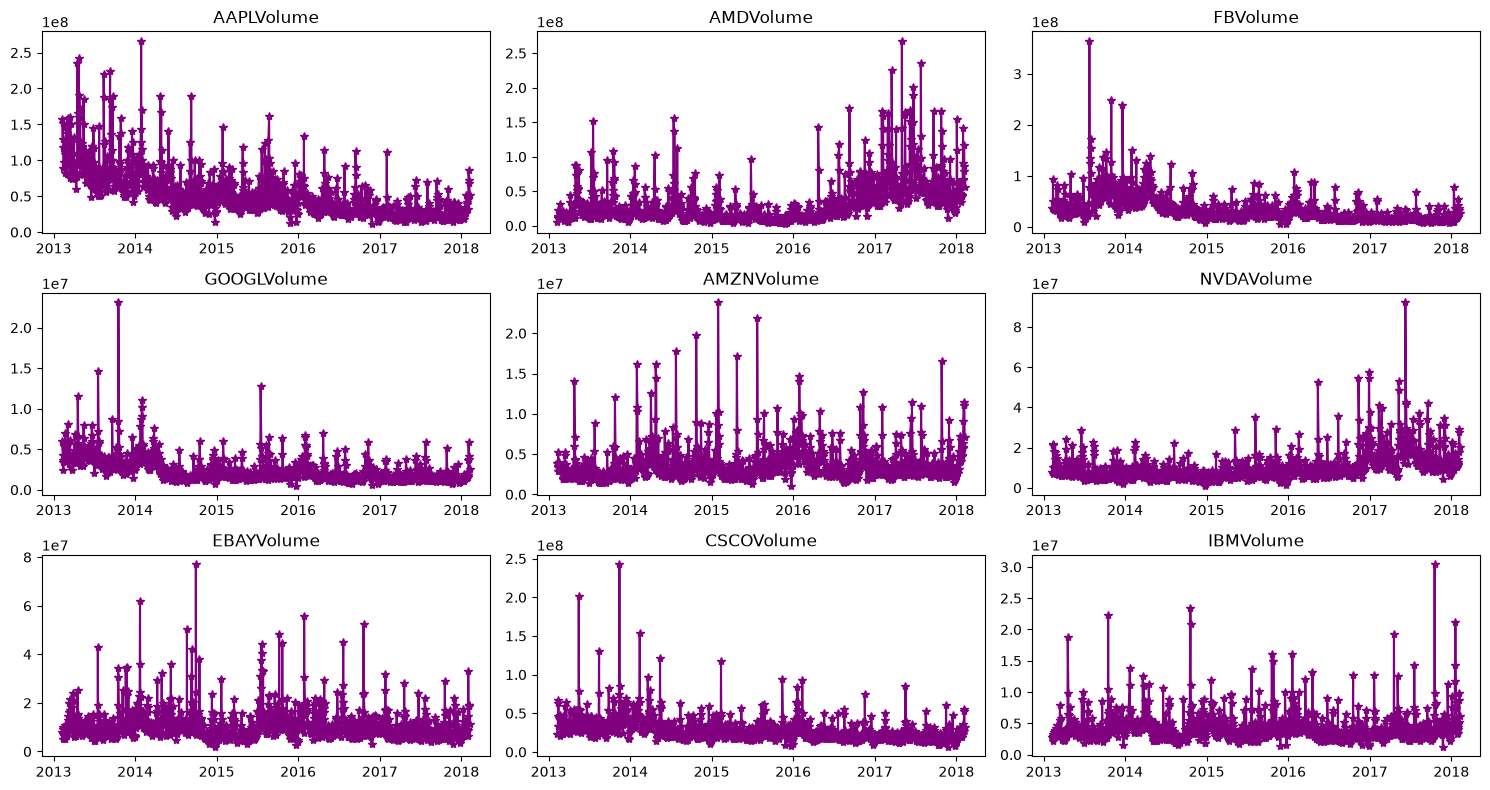

In [5]:
companies=['AAPL','AMD','FB','GOOGL','AMZN','NVDA','EBAY','CSCO','IBM']
plt.figure(figsize=(15,8))
for index, company in enumerate(companies,1):
    plt.subplot(3,3,index)
    c=data[data['Name']==company]
    plt.plot(c['date'],c['close'],c='r',label='close',marker='+')
    plt.plot(c['date'],c['open'],c='g',label='open',marker='^')
    plt.title(company)
    plt.legend()
    plt.tight_layout()

plt.figure(figsize=(15,8))
for index,company in enumerate(companies,1):
    plt.subplot(3,3,index)
    c=data[data['Name']==company]
    plt.plot(c['date'],c['volume'] ,c='purple',marker='*')
    plt.title(f"{company}Volume")
    plt.tight_layout()


ANALYZING APPLE STOCKS FROM 2013 TO 2014

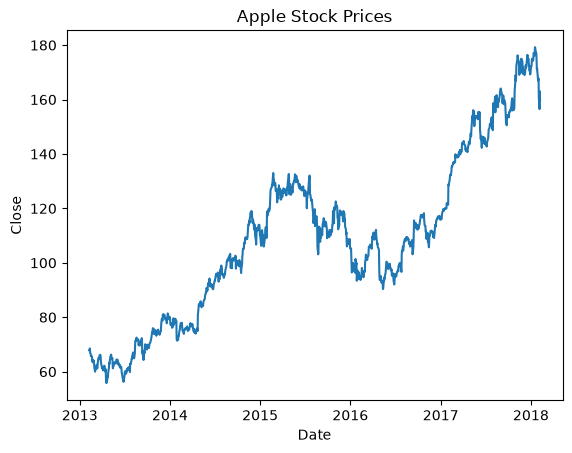

In [6]:
apple=data[data['Name']=='AAPL']
prediction_range=apple.loc[(apple['date']>datetime(2013,1,1)) & (apple['date']<datetime(2018,1,10))]
plt.plot(apple['date'],apple['close'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.title("Apple Stock Prices")
plt.show()


SELECTING A SUBSET OF THE WHOLE DATA AS THE TRAINING DATA TO BE LEFT WITH A SUBSET FOR VALIDATION AS WELL

In [7]:
close_data=apple.filter(['close'])
dataset=close_data.values
training=int(np.ceil(len(dataset)*.95))
print(training)

KeyboardInterrupt: 